This setup notebook contains boilerplate code for each exercise. Some of the answers depend on a particular dataset split or seed, so consult the boilerplate code for specifics even if you would like to program everything from scratch.
To install dependencies locally, download the pyproject.toml file from Canvas and place it in your assignment folder. Open a terminal, navigate to that folder, and run `pip install -e .` to install all required packages such as pandas, scikit-learn, and matplotlib. To install dependencies on Google Colab, first upload the pyproject.toml file to your Colab environment. After uploading, run `!pip install .` in a code cell to install all required packages.

# 1. PCA for Network Intrusion Detection

In [ ]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

def load_kdd_data(data_dir="./datasets/kdd_balanced"):
    """
    Load the balanced dataset from Parquet format (ultra-fast loading).
    
    Returns:
        D_balanced: Feature matrix (numpy array)
        is_normal_balanced: Boolean labels (numpy array)  
        original_indices: Original indices from full dataset (numpy array)
        df_balanced: Original dataframe subset (if available)
        metadata: Dataset metadata
    """
    from pathlib import Path
    import numpy as np
    import pandas as pd
    import json
    
    data_path = Path(data_dir)
    
    # Check if required files exist
    required_files = ["balanced_dataset.parquet", "metadata.json"]
    missing_files = [f for f in required_files if not (data_path / f).exists()]
    if missing_files:
        raise FileNotFoundError(f"Required files not found in {data_path}: {missing_files}")
    
    # Load main dataset (this is very fast with Parquet)
    df_main = pd.read_parquet(data_path / "balanced_dataset.parquet")
    
    # Extract components
    feature_cols = [col for col in df_main.columns if col.startswith('feature_')]
    D_balanced = df_main[feature_cols].values
    is_normal_balanced = df_main['is_normal'].values
    original_indices = df_main['original_index'].values
    
    # Load original dataframe if available
    df_balanced = None
    if (data_path / "original_data_balanced.parquet").exists():
        df_balanced = pd.read_parquet(data_path / "original_data_balanced.parquet")
    
    # Load metadata
    with open(data_path / "metadata.json", 'r') as f:
        metadata = json.load(f)
    
    print(f"Balanced dataset loaded from {data_path} (Parquet format)")
    print(f"  Features: {D_balanced.shape}")
    print(f"  Normal: {metadata['n_normal']:,}, Intrusion: {metadata['n_intrusion']:,}")
    
    return D_balanced, is_normal_balanced, original_indices, df_balanced, metadata

def compute_pca_from_intrusion_data(D_intrusion, r):
    """
    Compute PCA using SVD on intrusion data with rank r.
    
    Key insight: We train PCA on INTRUSION data, so normal data
    will have higher reconstruction error in this learned space.
    
    Returns:
        X: Principal components (learned from intrusion data)
        mu_intrusion: Mean vector of intrusion data
    """


def project_to_low_dimensional_space(D, X, mu_intrusion):
    """
    Project any data points into the low-dimensional space defined by
    intrusion-trained PCA components.
    """


def reconstruct_from_low_dimensional(Y, X, mu_intrusion):
    """Reconstruct data points from low-dimensional coordinates."""


def compute_reconstruction_error(original, reconstructed):
    """Compute L2 reconstruction error."""


In [ ]:
D_balanced, is_normal_balanced, original_indices, _, metadata = load_kdd_data()

# Your code here

# 2. Netflix Recommender System

In [13]:
from pathlib import Path
import numpy as np
import pandas as pd


def load_ratings_data_pandas(data_dir="ml-latest-small/"):
    """Load data using pandas dataframes."""
    data_dir = Path(data_dir)
    assert data_dir.exists(), f"{data_dir} does not exist"

    return pd.read_csv(data_dir / 'ratings.csv',sep=',')


def load_movies_data_pandas(data_dir="ml-latest-small/"):
    """Load data using pandas dataframes."""
    data_dir = Path(data_dir)
    assert data_dir.exists(), f"{data_dir} does not exist"
    return pd.read_csv(data_dir / 'movies.csv')


def filter_data(ratings_data: pd.DataFrame, movies_data: pd.DataFrame):
    """Filter data. Too few ratings prevent effective use of matrix completion."""
    ratings_data = ratings_data.pivot(
        index='userId',
        columns='movieId',
        values='rating'
    ).fillna(0)

    keep_movie = (ratings_data != 0).sum(axis=0) > 100
    ratings_data = ratings_data.loc[:, keep_movie]

    # Filter movies_data by movieId (columns of ratings_data after filtering)
    movies_data = movies_data[movies_data['movieId'].isin(ratings_data.columns)]

    keep_user = (ratings_data != 0).sum(axis=1) >= 5
    ratings_data = ratings_data.loc[keep_user, :]

    return ratings_data, movies_data


def print_data_summary(ratings: pd.DataFrame):
    n_users = ratings.shape[0]
    n_movies = ratings.shape[1]
    n_ratings = (ratings != 0).sum().sum()
    density = n_ratings / (n_users * n_movies)

    print(f"Dataset Summary")
    print(f"----------------")
    print(f"Users: {n_users}")
    print(f"Movies: {n_movies}")
    print(f"Total Ratings: {n_ratings}")
    print(f"Data Density: {density:.4f} (fraction of observed ratings)")


def load_ratings_data(data_dir="ml-latest-small/", print_summary=False):
    """Load data in numpy format."""
    ratings, movies = filter_data(
        load_ratings_data_pandas(data_dir=data_dir),
        load_movies_data_pandas(data_dir=data_dir)
    )
    if print_summary:
        print_data_summary(ratings)
    return ratings.to_numpy()


def load_movies_data(data_dir="datasets/ml-latest-small") -> tuple[pd.DataFrame, pd.Series]:
    _, movies_df = filter_data(
        load_ratings_data_pandas(data_dir=data_dir),
        load_movies_data_pandas(data_dir=data_dir)
    )
    return movies_df


def matrix_completion(D, n_features, n_movies, n_users, t_max=100, lambd=0.1):
    np.random.seed(0)
    X = np.random.normal(size=(n_movies, n_features))
    Y = np.random.normal(size=(n_users, n_features))

    O = (D != 0).astype(float)
    for iteration in range(t_max):
        for k in range(n_movies):
            obs = np.where(O[:, k])[0]
            if len(obs) == 0: continue
            Y_obs = Y[obs]
            d_obs = D[obs, k]
            X[k] = np.linalg.solve(Y_obs.T @ Y_obs + lambd * np.eye(n_features), Y_obs.T @ d_obs)

        for i in range(n_users):
            obs = np.where(O[i, :])[0]
            if len(obs) == 0: continue
            X_obs = X[obs]
            d_obs = D[i, obs]
            Y[i] = np.linalg.solve(X_obs.T @ X_obs + lambd * np.eye(n_features), X_obs.T @ d_obs)
    return X, Y

In [14]:
# ratings = load_ratings_data("datasets/ml-latest-small", print_summary=True)

D = load_ratings_data("datasets/ml-latest-small", print_summary=True)
movies_df = load_movies_data("datasets/ml-latest-small")
n_users, n_movies = D.shape

movie_idcol = {mid: i for i, mid in enumerate(movies_df["movieId"])}
result_cols = {
    "Jumanji (1995)": movie_idcol[2],
    "Monty Python and the Holy Grail (1975)": movie_idcol[1136],
    "Matrix, The (1999)": movie_idcol[2571],
    "Fight Club (1999)": movie_idcol[2959],
}

print("2a")
X, Y = matrix_completion(D, n_features=20, n_movies=n_movies, n_users=n_users)
pred0 = Y[0] @ X.T
O = (D != 0).astype(float)
print(((D - O * (Y @ X.T)) ** 2).sum() / O.sum())
for name, col in result_cols.items():
    print(f"{name}: {pred0[col]}")

print("2b")
for lambd in [0.01, 0.1, 0.5]:
    X_l, Y_l = matrix_completion(D, n_features=20, n_movies=n_movies, n_users=n_users, lambd=lambd)
    pred_l = Y_l @ X_l.T
    err = ((D - O * pred_l) ** 2).sum() / O.sum()
    missing = pred_l.ravel()[O.ravel() == 0]
    mp_col = result_cols["Monty Python and the Holy Grail (1975)"]
    print(f"l={lambd}: err={err}, var={np.var(missing)}, "
          f"out percent={np.mean((missing < 0.5) | (missing > 5)) * 100}, "
          f"mean={np.mean(missing)}, Monty Python rating: {pred_l[0, mp_col]}")

print("2c")
for lambd in [0.01, 0.5]:
    X_l, Y_l = matrix_completion(D, n_features=20, n_movies=n_movies, n_users=n_users, lambd=lambd)
    print((Y_l[0] @ X_l.T)[result_cols["Monty Python and the Holy Grail (1975)"]])

Dataset Summary
----------------
Users: 556
Movies: 134
Total Ratings: 19694
Data Density: 0.2643 (fraction of observed ratings)
2a
0.09391714344491053
Jumanji (1995): 3.7598285551846677
Monty Python and the Holy Grail (1975): 4.6420681886644
Matrix, The (1999): 4.7468516837628005
Fight Club (1999): 4.77566672934744
2b
l=0.01: err=0.09263601234802842, var=6.161466574587517, out percent=26.672140120415982, mean=3.3258120508881346, Monty Python rating: 4.787195068246432
l=0.1: err=0.09391714344491053, var=3.413897431524206, out percent=19.507389162561577, mean=3.0314893258509388, Monty Python rating: 4.642068188664401
l=0.5: err=0.10167419557704198, var=1.315182774487914, out percent=7.45666849115125, mean=3.346260494445969, Monty Python rating: 5.2068470162324605
2c
4.787195068246431
5.2068470162324605


# 3. Support Vector Machines

In [ ]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
seed = 42
np.random.seed(seed)

# Load digits dataset
digits = datasets.load_digits()
X, y = digits.data, digits.target

# Train-test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
print(digits.DESCR)

# 4. Image Classification With Neural Networks

In [1]:
"""
CNN Embedding Space Visualization

This educational module demonstrates:
- ResNet-style architecture with skip connections
- Embedding space learning for visualization
- Domain transfer between MNIST and Fashion-MNIST
- Decision boundary visualization
"""

from dataclasses import dataclass
from pathlib import Path
from typing import Tuple, Optional, Callable
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


@dataclass
class Config:
    """Configuration parameters for the model and training."""

    # Model architecture
    embedding_dim: int = 2
    num_classes: int = 10

    # Training hyperparameters
    learning_rate: float = 0.9 
    momentum: float = 0.9
    weight_decay: float = 5e-4
    batch_size: int = 128
    epochs: int = 5
    dropout_rate_1: float = 0.9
    dropout_rate_2: float = 0.9

    # Visualization
    viz_samples: int = 100
    viz_zoom: float = 0.7
    grid_resolution: float = 0.1 
    
    # Paths
    checkpoint_dir: Path = Path("checkpoint")
    model_filename: str = "embedding_model.pth"

    @property
    def device(self) -> str:
        """Get the appropriate device for computation."""
        return 'cuda' if torch.cuda.is_available() else 'cpu'


class ResidualBlock(nn.Module):
    """
    Residual block with skip connections and grouped convolutions.

    Implements: output = input + F(input)
    where F is a residual function composed of BatchNorm→ReLU→Conv layers.
    """

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, groups: int = 1):
        super().__init__()

        groups = min(groups, min(in_channels, out_channels))

        # Main convolution pathway
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size,
                              padding="same", groups=groups)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size,
                              padding="same", groups=min(groups, out_channels))

        # Skip connection (identity or dimension adjustment)
        self.skip_connection = (
            nn.Identity() if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, kernel_size=1, padding="same")
        )

        # Pre-activation normalization layers
        self.norm1 = nn.BatchNorm2d(in_channels)
        self.norm2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass implementing residual connection."""
        identity = self.skip_connection(x)

        # Residual pathway: BatchNorm → ReLU → Conv → BatchNorm → ReLU → Conv
        out = self.conv1(self.relu(self.norm1(x)))
        out = self.conv2(self.relu(self.norm2(out)))

        return identity + out


class EmbeddingNetwork(nn.Module):
    """
    CNN that maps input images to low-dimensional embedding space.

    Uses global average pooling instead of flattening to reduce overfitting
    and make the model robust to different input sizes.
    """

    def __init__(self, embedding_dim: int, dropout_rate_1: float, dropout_rate_2: float):
        super().__init__()

        # Initial feature extraction
        self.initial_conv = nn.Conv2d(1, 32, kernel_size=5, padding="same")
        self.initial_norm = nn.BatchNorm2d(32)

        # First residual block set (32 channels, groups=2)
        self.res_block1 = ResidualBlock(32, 32, kernel_size=3, groups=2)
        self.res_block2 = ResidualBlock(32, 32, kernel_size=3, groups=2)

        # Spatial downsampling
        self.pool = nn.MaxPool2d(2)
        self.norm_after_pool = nn.BatchNorm2d(32)

        # Second residual block set (64 channels, groups=4)
        self.res_block3 = ResidualBlock(32, 64, kernel_size=3, groups=4)
        self.res_block4 = ResidualBlock(64, 64, kernel_size=3, groups=4)

        # Final processing
        self.final_norm = nn.BatchNorm1d(64)
        self.fc1 = nn.Linear(64, 128)
        self.fc2 = nn.Linear(128, embedding_dim)

        # Regularization
        self.dropout1 = nn.Dropout(dropout_rate_1)
        self.dropout2 = nn.Dropout(dropout_rate_2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass mapping images to embedding space.

        Args:
            x: Input tensor of shape (batch_size, 1, 28, 28)

        Returns:
            Embedding tensor of shape (batch_size, embedding_dim)
        """
        out = F.relu(self.initial_norm(self.initial_conv(x)))

        # First round of residual blocks
        out = self.res_block2(self.res_block1(out))

        # Pooling
        out = self.norm_after_pool(self.pool(out))

        # Second round of residual blocks
        out = self.res_block4(self.res_block3(out))

        # Global average pooling
        out = torch.mean(out, dim=(-1, -2))
        out = self.final_norm(out)

        # Map to embedding space
        out = self.dropout1(out)
        out = F.relu(self.fc1(out))
        out = self.dropout2(out)
        out = self.fc2(out)

        return out


class EmbeddingClassifier(nn.Module):
    """Complete model combining embedding network with classifier."""

    def __init__(self, embedding_dim: int, num_classes: int, config: Config):
        super().__init__()
        self.embedding_net = EmbeddingNetwork(
            embedding_dim, config.dropout_rate_1, config.dropout_rate_2
        )
        self.classifier = nn.Linear(embedding_dim, num_classes, bias=True)

        nn.init.normal_(self.classifier.weight, 0, 0.01)
        nn.init.constant_(self.classifier.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass for training and evaluation."""
        embeddings = self.embedding_net(x)
        return self.classifier(embeddings)

    def get_embeddings(self, x: torch.Tensor) -> torch.Tensor:
        """Extract embeddings for visualization."""
        return self.embedding_net(x)

    def get_probabilities(self, x: torch.Tensor) -> torch.Tensor:
        """Get class probabilities for confidence visualization."""
        embeddings = self.embedding_net(x)
        return F.softmax(self.classifier(embeddings), dim=1)


def create_data_loaders(dataset_class, config: Config) -> Tuple[DataLoader, DataLoader]:
    """
    Create training and test data loaders.

    Args:
        dataset_class: torchvision dataset class (MNIST or FashionMNIST)
        config: Configuration object

    Returns:
        Tuple of (train_loader, test_loader)
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))  # MNIST standard values
    ])

    # Training data
    train_dataset = dataset_class(root='./data', train=True, download=True, transform=transform)
    if config.num_classes < 10:
        mask = train_dataset.targets < config.num_classes
        train_dataset.targets = train_dataset.targets[mask]
        train_dataset.data = train_dataset.data[mask]

    train_loader = DataLoader(
        train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=2
    )

    # Test data
    test_dataset = dataset_class(root='./data', train=False, download=True, transform=transform)
    if config.num_classes < 10:
        mask = test_dataset.targets < config.num_classes
        test_dataset.targets = test_dataset.targets[mask]
        test_dataset.data = test_dataset.data[mask]

    test_loader = DataLoader(
        test_dataset, batch_size=config.batch_size, shuffle=False, num_workers=2
    )

    return train_loader, test_loader


@dataclass
class EpochMetrics:
    """Container for epoch training/evaluation metrics."""
    accuracy: float
    avg_confidence: float
    avg_loss: float
    total_samples: int
    elapsed_time: Optional[float] = None


def compute_batch_metrics(logits: torch.Tensor, targets: torch.Tensor, loss: torch.Tensor) -> Tuple[int, float, int]:
    """
    Compute metrics for a single batch.

    Args:
        logits: Model output logits
        targets: Ground truth labels
        loss: Computed loss for the batch

    Returns:
        Tuple of (correct_predictions, total_confidence, batch_size)
    """
    probabilities = F.softmax(logits, dim=1)
    confidences, predictions = probabilities.max(1)

    correct_predictions = predictions.eq(targets).sum().item()
    total_confidence = confidences.sum().item()
    batch_size = targets.size(0)

    return correct_predictions, total_confidence, batch_size


def run_epoch(
    model: nn.Module,
    criterion,
    data_loader: DataLoader,
    device: str,
    optimizer=None,
    is_training: bool = True
) -> EpochMetrics:
    """
    Run one epoch of training or evaluation.

    Args:
        model: PyTorch model
        criterion: Loss function
        data_loader: Data loader
        device: Device to run on
        optimizer: Optimizer (required if is_training=True)
        is_training: Whether to run in training mode

    Returns:
        EpochMetrics containing all computed metrics
    """
    if is_training:
        if optimizer is None:
            raise ValueError("Optimizer required for training mode")
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_confidence = 0.0
    total_samples = 0

    start_time = time.time()
    context_manager = torch.no_grad() if not is_training else torch.enable_grad()

    with context_manager:
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            if is_training:
                optimizer.zero_grad()

            logits = model(inputs)
            loss = criterion(logits, targets)

            if torch.isnan(loss):
                print("Warning: NaN loss detected")

            if is_training:
                loss.backward()
                optimizer.step()

            # Compute batch metrics (always without gradients for metrics)
            with torch.no_grad():
                batch_correct, batch_confidence, batch_size = compute_batch_metrics(logits, targets, loss)

                total_loss += loss.item()
                total_correct += batch_correct
                total_confidence += batch_confidence
                total_samples += batch_size

    # Calculate final metrics
    if total_samples == 0:
        print("Warning: No samples processed")
        return EpochMetrics(0, 0, float('inf'), 0, time.time() - start_time)

    accuracy = 100.0 * total_correct / total_samples
    avg_confidence = 100.0 * total_confidence / total_samples
    avg_loss = total_loss / len(data_loader)
    elapsed_time = time.time() - start_time

    return EpochMetrics(
        accuracy=accuracy,
        avg_confidence=avg_confidence,
        avg_loss=avg_loss,
        total_samples=total_samples,
        elapsed_time=elapsed_time
    )


def train_epoch(model: nn.Module, criterion, optimizer, data_loader: DataLoader, device: str) -> Tuple[float, float]:
    """
    Train model for one epoch.

    Returns:
        Tuple of (accuracy, average_confidence)
    """
    metrics = run_epoch(model, criterion, data_loader, device, optimizer, is_training=True)

    print(f'Train - Loss: {metrics.avg_loss:.3f} | '
          f'Acc: {metrics.accuracy:.3f}% ({int(metrics.accuracy * metrics.total_samples / 100)}/{metrics.total_samples}) | '
          f'Conf: {metrics.avg_confidence:.2f}% | Time: {metrics.elapsed_time:.2f}s')

    return metrics.accuracy, metrics.avg_confidence


def evaluate_model(model: nn.Module, criterion, data_loader: DataLoader, device: str) -> Tuple[float, float]:
    """
    Evaluate model on test data.

    Returns:
        Tuple of (accuracy, average_confidence)
    """
    metrics = run_epoch(model, criterion, data_loader, device, optimizer=None, is_training=False)

    print(f'Test  - Loss: {metrics.avg_loss:.3f} | '
          f'Acc: {metrics.accuracy:.3f}% ({int(metrics.accuracy * metrics.total_samples / 100)}/{metrics.total_samples}) | '
          f'Conf: {metrics.avg_confidence:.2f}%')

    return metrics.accuracy, metrics.avg_confidence


def save_model(model: nn.Module, accuracy: float, config: Config) -> None:
    """Save model checkpoint."""
    config.checkpoint_dir.mkdir(exist_ok=True)

    checkpoint = {
        'model_state_dict': model.state_dict(),
        'accuracy': accuracy,
        'config': {
            'embedding_dim': config.embedding_dim,
            'num_classes': config.num_classes,
            'dropout_rate_1': config.dropout_rate_1,
            'dropout_rate_2': config.dropout_rate_2,
        }
    }

    save_path = config.checkpoint_dir / config.model_filename
    torch.save(checkpoint, save_path)
    print(f"Model saved to {save_path}")


def load_model(config: Config) -> EmbeddingClassifier:
    """Load model from checkpoint."""
    load_path = config.checkpoint_dir / config.model_filename

    model = EmbeddingClassifier(config.embedding_dim, config.num_classes, config)
    checkpoint = torch.load(load_path, map_location='cpu')
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print(f"Model loaded from {load_path}")
    print(f"Loaded model accuracy: {checkpoint['accuracy']:.2f}%")

    return model


def plot_decision_boundary(
    model: EmbeddingClassifier,
    bounds: Tuple[float, float, float, float],
    config: Config,
    show_classes: bool = False
) -> None:
    """
    Plot decision boundary or confidence map in embedding space.

    Args:
        model: Trained model
        bounds: (x_min, x_max, y_min, y_max) for plot region
        config: Configuration object
        show_classes: If True, show class assignments; if False, show confidence
    """
    x_min, x_max, y_min, y_max = bounds

    if not all(np.isfinite([x_min, x_max, y_min, y_max])):
        print("Warning: Invalid bounds detected, using default range")
        x_min, x_max, y_min, y_max = -10, 10, -10, 10

    if x_max <= x_min:
        x_max = x_min + 10
    if y_max <= y_min:
        y_max = y_min + 10

    x = np.arange(x_min, x_max, config.grid_resolution, dtype=np.float32)
    y = np.arange(y_min, y_max, config.grid_resolution, dtype=np.float32)

    if len(x) == 0 or len(y) == 0:
        print("Warning: Empty grid, adjusting resolution")
        x = np.linspace(x_min, x_max, 50, dtype=np.float32)
        y = np.linspace(y_min, y_max, 50, dtype=np.float32)

    xx, yy = np.meshgrid(x, y)

    # Create grid points for evaluation
    grid_points = torch.from_numpy(
        np.array([xx.ravel(), yy.ravel()]).T
    ).float().to(config.device)

    # Get model predictions
    with torch.no_grad():
        probabilities = torch.softmax(model.classifier(grid_points), dim=1)
        probabilities = probabilities.cpu().numpy()

    # Reshape for contour plotting
    if show_classes:
        class_assignments = probabilities.argmax(axis=1).reshape(xx.shape)
        plt.contourf(xx, yy, class_assignments, levels=config.num_classes, cmap='tab10', alpha=0.7)
        plt.colorbar(label='Predicted Class')
    else:
        confidence_map = probabilities.max(axis=1).reshape(xx.shape)
        contour = plt.contourf(xx, yy, confidence_map, levels=20, cmap='viridis', alpha=0.7)
        plt.clim(0, 1)
        plt.colorbar(contour, label='Max Confidence')

    plt.axis('equal')


def scatter_images_on_embeddings(
    images: torch.Tensor,
    embeddings: torch.Tensor,
    config: Config
) -> None:
    """
    Scatter actual images at their embedding coordinates.

    Args:
        images: Input images tensor
        embeddings: Corresponding embedding coordinates
        config: Configuration object
    """
    num_samples = min(images.shape[0], config.viz_samples)

    for i in range(num_samples):
        image = images[i].squeeze().cpu().numpy()
        embedding_pos = (embeddings[i, 0].item(), embeddings[i, 1].item())

        if not all(np.isfinite(embedding_pos)):
            continue

        offset_image = OffsetImage(image, cmap="gray", zoom=config.viz_zoom)
        annotation_box = AnnotationBbox(
            offset_image, embedding_pos, xycoords='data', frameon=False, alpha=0.7
        )
        plt.gca().add_artist(annotation_box)


def visualize_embedding_space(
    model: EmbeddingClassifier,
    data_loader: DataLoader,
    config: Config,
    title: str = "Embedding Space Visualization"
) -> None:
    """
    Create comprehensive visualization of embedding space.

    Args:
        model: Trained model
        data_loader: Data loader for visualization
        config: Configuration object
        title: Plot title
    """
    model.eval()

    # Get batch of data and embeddings
    inputs, _ = next(iter(data_loader))
    inputs = inputs.to(config.device)

    with torch.no_grad():
        embeddings = model.get_embeddings(inputs).cpu()

    valid_embeddings = embeddings[torch.isfinite(embeddings).all(dim=1)]

    if len(valid_embeddings) == 0:
        print("Warning: No valid embeddings found, using default bounds")
        bounds = (-10, 10, -10, 10)
    else:
        margin = 3
        x_vals = valid_embeddings[:, 0]
        y_vals = valid_embeddings[:, 1]

        bounds = (
            float(x_vals.min() - margin),
            float(x_vals.max() + margin),
            float(y_vals.min() - margin),
            float(y_vals.max() + margin)
        )

    # Create visualization
    plt.figure(figsize=(10, 8))
    plot_decision_boundary(model, bounds, config)
    scatter_images_on_embeddings(inputs.cpu(), embeddings, config)

    plt.title(title)
    plt.xlabel('Embedding Dimension 1')
    plt.ylabel('Embedding Dimension 2')
    plt.tight_layout()

In [2]:
"""Main training and evaluation pipeline."""
# Edit configuration here like so
config = Config(
    epochs=15,
    learning_rate=0.001,
    dropout_rate_1=0.3,
    dropout_rate_2=0.3
)

print("CNN Embedding Space Learning")
print("=" * 50)
print(f"Using device: {config.device}")

# Create data loaders
print("\nPreparing MNIST data...")
mnist_train_loader, mnist_test_loader = create_data_loaders(datasets.MNIST, config)

# Create and setup model
print("Building model...")
model = EmbeddingClassifier(config.embedding_dim, config.num_classes, config)
model = model.to(config.device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=config.learning_rate,
    momentum=config.momentum,
    weight_decay=config.weight_decay
)

# Training loop
print("\nTraining...")
best_accuracy = 0.0

for epoch in range(config.epochs):
    print(f'\nEpoch {epoch + 1}/{config.epochs}:')
    train_epoch(model, criterion, optimizer, mnist_train_loader, config.device)
    test_acc, _ = evaluate_model(model, criterion, mnist_test_loader, config.device)

    if test_acc > best_accuracy:
        best_accuracy = test_acc

# Save model
save_model(model, best_accuracy, config)

CNN Embedding Space Learning
Using device: cuda

Preparing MNIST data...
Building model...
Total parameters: 63,584

Training...

Epoch 1/15:
Train - Loss: 2.223 | Acc: 18.730% (11238/60000) | Conf: 12.92% | Time: 17.39s
Test  - Loss: 1.970 | Acc: 21.780% (2178/10000) | Conf: 25.80%

Epoch 2/15:
Train - Loss: 1.675 | Acc: 30.690% (18414/60000) | Conf: 30.17% | Time: 17.14s
Test  - Loss: 1.274 | Acc: 43.480% (4347/10000) | Conf: 37.92%

Epoch 3/15:
Train - Loss: 1.044 | Acc: 56.568% (33941/60000) | Conf: 47.65% | Time: 17.15s
Test  - Loss: 0.832 | Acc: 65.020% (6502/10000) | Conf: 57.76%

Epoch 4/15:
Train - Loss: 0.738 | Acc: 71.290% (42774/60000) | Conf: 62.02% | Time: 17.05s
Test  - Loss: 0.669 | Acc: 73.590% (7359/10000) | Conf: 68.17%

Epoch 5/15:
Train - Loss: 0.586 | Acc: 79.643% (47786/60000) | Conf: 69.37% | Time: 17.09s
Test  - Loss: 0.684 | Acc: 76.800% (7680/10000) | Conf: 71.41%

Epoch 6/15:
Train - Loss: 0.493 | Acc: 84.997% (50998/60000) | Conf: 73.90% | Time: 17.10s
Test


Visualizing MNIST embeddings...


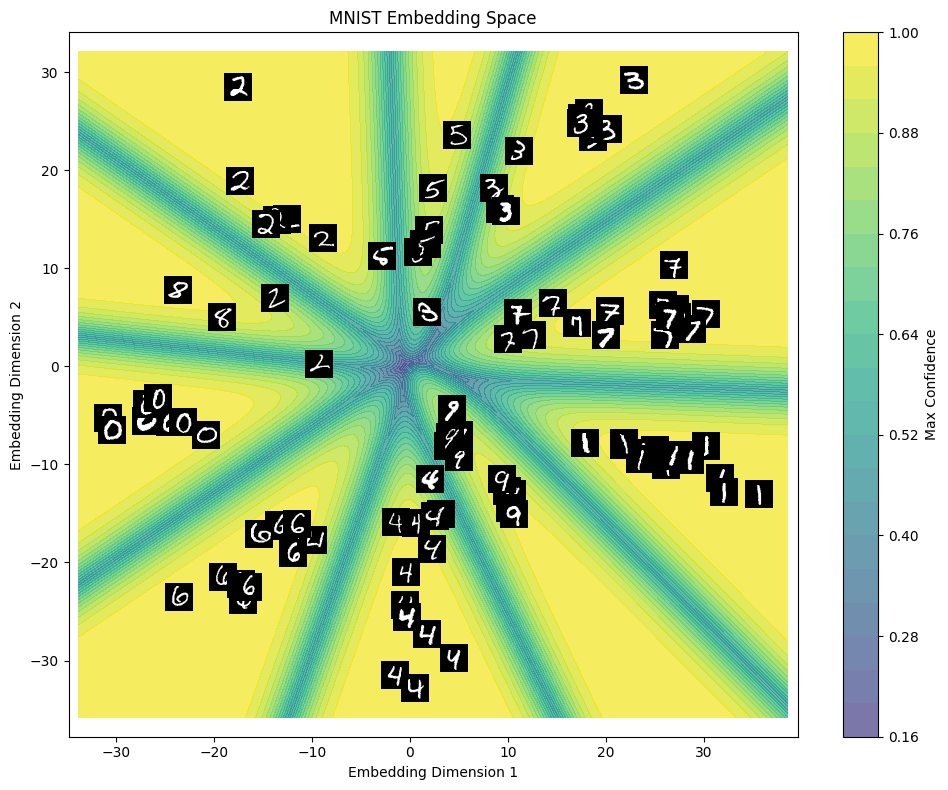

1.6%


Testing domain transfer with Fashion-MNIST...


100.0%
100.0%
100.0%
100.0%


Test  - Loss: 22.184 | Acc: 11.690% (1169/10000) | Conf: 84.52%


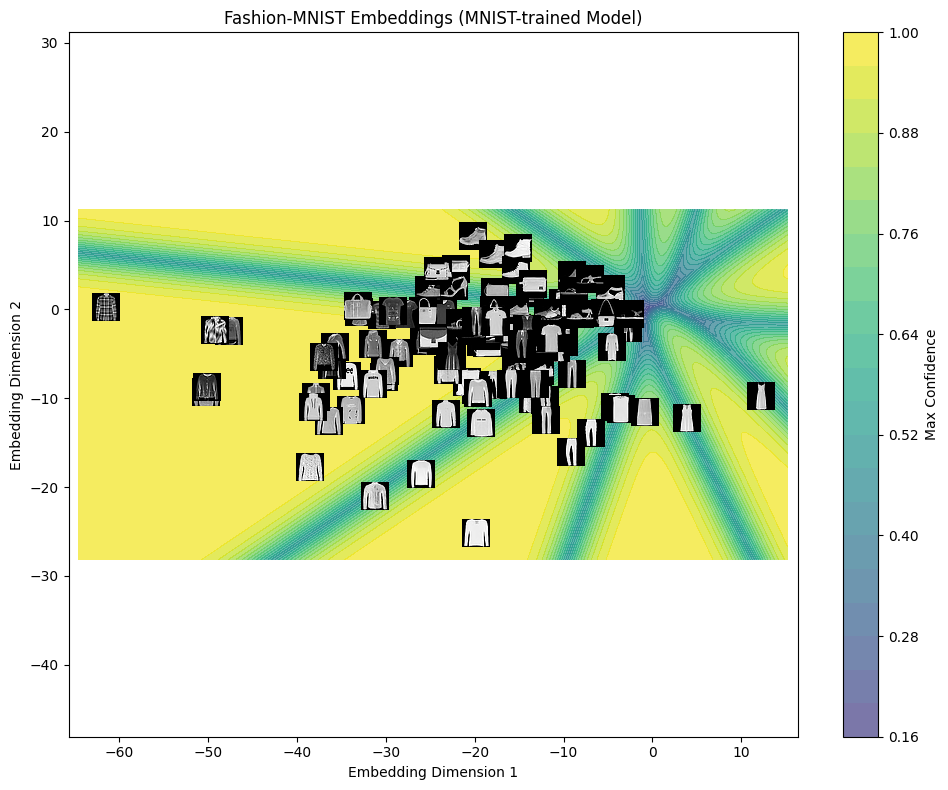

In [3]:
# Visualize MNIST embeddings
print("\nVisualizing MNIST embeddings...")
try:
    visualize_embedding_space(model, mnist_test_loader, config, "MNIST Embedding Space")
    plt.show()
except Exception as e:
    print(f"Visualization error: {e}")

# Domain transfer experiment
print("\nTesting domain transfer with Fashion-MNIST...")
fashion_train_loader, fashion_test_loader = create_data_loaders(datasets.FashionMNIST, config)

fashion_acc, _ = evaluate_model(model, criterion, fashion_test_loader, config.device)

# Visualize Fashion-MNIST embeddings
try:
    visualize_embedding_space(
        model, fashion_test_loader, config,
        "Fashion-MNIST Embeddings (MNIST-trained Model)"
    )
    plt.show()
except Exception as e:
    print(f"Visualization error: {e}")

In [4]:
W = model.classifier.weight.detach().cpu().numpy()
b = model.classifier.bias.detach().cpu().numpy()

print("W shape:", W.shape)
print(W)

print("\nb shape:", b.shape)
print(b)

W shape: (10, 2)
[[-1.1739     -0.35938355]
 [ 1.1264423  -0.37789214]
 [-0.68583477  1.0402158 ]
 [ 0.80213344  0.8494863 ]
 [-0.06134542 -1.198376  ]
 [ 0.05457053  1.0646245 ]
 [-0.7792271  -0.9447034 ]
 [ 1.1530591   0.33077428]
 [-1.0850834   0.463634  ]
 [ 0.63920504 -0.8625633 ]]

b shape: (10,)
[-0.33971894 -0.7461488  -0.10575521 -0.6487483  -0.21383485  0.61102504
  0.01490234  0.02470328  0.12408131  1.2794951 ]


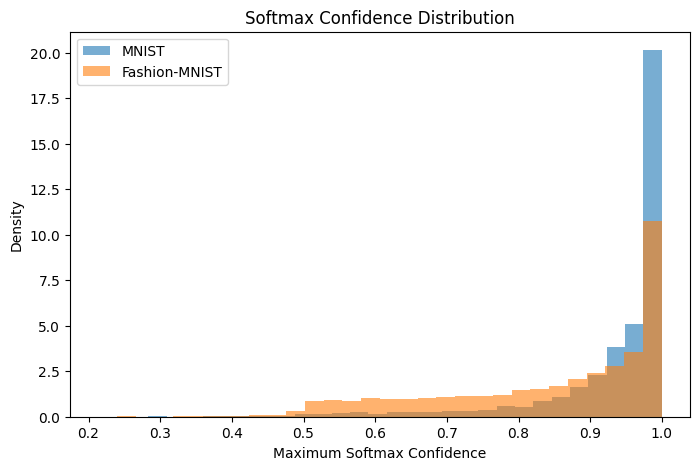

MNIST mean confidence: 0.9330
Fashion-MNIST mean confidence: 0.8452


In [7]:
# PART 3b: compute the maximum softmax confidence for each sample.
# this allows us to compare how confident the MNIST-trained model is on
# in-distribution data (MNIST) versus out-of-distribution data (Fashion-MNIST).

def get_max_confidences(model, data_loader, config):
    model.eval()
    scores = []

    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(config.device)

            logits = model(inputs)
            probabilities = torch.softmax(logits, dim=1)

            max_confidence, _ = probabilities.max(dim=1)
            scores.extend(max_confidence.cpu().numpy())

    return np.array(scores)

# collect confidence scores for both datasets
mnist_conf = get_max_confidences(model, mnist_test_loader, config)
fashion_conf = get_max_confidences(model, fashion_test_loader, config)

# visualize the confidence distributions.
# if softmax confidence is a good uncertainty estimate, Fashion-MNIST
# should generally receive lower confidence than MNIST.
plt.figure(figsize=(8, 5))
plt.hist(mnist_conf, bins=30, alpha=0.6, density=True, label="MNIST")
plt.hist(fashion_conf, bins=30, alpha=0.6, density=True, label="Fashion-MNIST")

plt.xlabel("Maximum Softmax Confidence")
plt.ylabel("Density")
plt.title("Softmax Confidence Distribution")
plt.legend()
plt.show()

print(f"MNIST mean confidence: {mnist_conf.mean():.4f}")
print(f"Fashion-MNIST mean confidence: {fashion_conf.mean():.4f}")

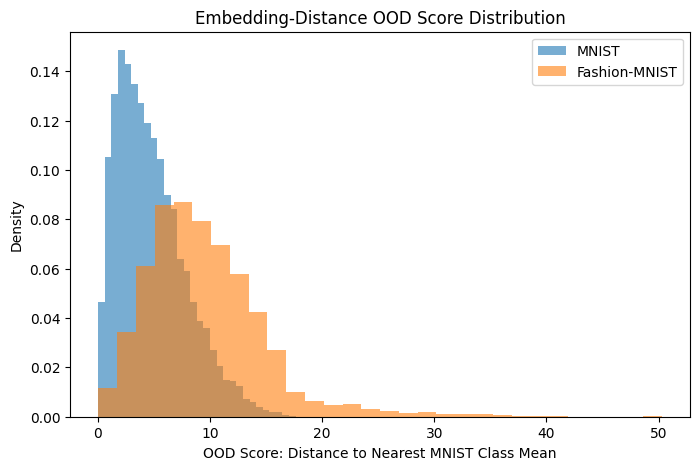

MNIST mean OOD score: 4.7652
Fashion-MNIST mean OOD score: 9.5835


In [8]:
# PART 3b: extract the 2d embeddings and labels from a data loader

def get_embeddings_and_labels(model, data_loader, config):
    model.eval()
    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(config.device)
            embeddings = model.get_embeddings(inputs)

            all_embeddings.append(embeddings.cpu())
            all_labels.append(labels.cpu())

    return torch.cat(all_embeddings).numpy(), torch.cat(all_labels).numpy()


# get embeddings for mnist and fashion-mnist
mnist_train_embeddings, mnist_train_labels = get_embeddings_and_labels(model, mnist_train_loader, config)
mnist_test_embeddings, mnist_test_labels = get_embeddings_and_labels(model, mnist_test_loader, config)
fashion_test_embeddings, fashion_test_labels = get_embeddings_and_labels(model, fashion_test_loader, config)


# compute one class mean per mnist digit using only the mnist training embeddings
# this makes the ood rule depend only on in-distribution data
class_means = []

for class_id in range(config.num_classes):
    class_embeddings = mnist_train_embeddings[mnist_train_labels == class_id]
    class_means.append(class_embeddings.mean(axis=0))

class_means = np.stack(class_means)


# define the ood score as the distance to the nearest mnist class mean
# larger values mean the point is further away from all learned digit clusters
def nearest_class_mean_distance(embeddings, class_means):
    distances = np.linalg.norm(
        embeddings[:, None, :] - class_means[None, :, :],
        axis=2
    )

    return distances.min(axis=1)


# compute the ood score for in-distribution mnist and ood fashion-mnist
mnist_ood_score = nearest_class_mean_distance(mnist_test_embeddings, class_means)
fashion_ood_score = nearest_class_mean_distance(fashion_test_embeddings, class_means)


# plot the score distributions
# good ood separation would mean fashion-mnist has clearly larger scores than mnist
plt.figure(figsize=(8, 5))
plt.hist(mnist_ood_score, bins=30, alpha=0.6, density=True, label="MNIST")
plt.hist(fashion_ood_score, bins=30, alpha=0.6, density=True, label="Fashion-MNIST")

plt.xlabel("OOD Score: Distance to Nearest MNIST Class Mean")
plt.ylabel("Density")
plt.title("Embedding-Distance OOD Score Distribution")
plt.legend()
plt.show()

print(f"MNIST mean OOD score: {mnist_ood_score.mean():.4f}")
print(f"Fashion-MNIST mean OOD score: {fashion_ood_score.mean():.4f}")